# Running Our Compression Methods and Testing them

This notebook is for running our output validation methods (currently METEOR and BERTScore).

There is also some methods for creating LLM outputs, and a few compression methods.

In [1]:
from nltk.tokenize import word_tokenize

# test_text = """
#     The quick brown fox jumps over the lazy dog. This is a very common pangram
#     that has been used for testing typewriters and computer keyboards because it
#     contains every single letter of the alphabet. It has been in use since at
#     least the late 1800s and it remains popular today in the modern era.
#     """


test_text = """You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit.
    
    What is the main conclusion of this article in under 100 words?"""

# Caveman Compression

This method is our simple method which removes certain stopwords from sentences.

Output sounds like a caveman talking "Make Fire, eat dinosaur!"

In [2]:
## Caveman Compressor
# This will be our simple baseline compression method which removes certain unnecessary words from the prompt.

import re

stopwords = {
    # Articles
    'a', 'an', 'the',
    # Auxiliary verbs
    'is', 'are', 'was', 'were', 'am', 'be', 'been', 'being',
    'has', 'have', 'had', 'having',
    'do', 'does', 'did', 'doing',
    'will', 'would', 'shall', 'should', 'may', 'might', 'must', 'can', 'could',
    # Common but often non-essential words
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'from',
    'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once',
    # Pronouns (keeping some key ones, removing others)
    'this', 'that', 'these', 'those',
    # Other
    'there', 'here', 'where',
    'very', 'just', 'really', 'quite', 'too', 'so',
}
#TODO: can we change this for a library of stop words?

def caveman_compressor(text: str, stopwords: set) -> str:
    """
    Compress text by removing stopwords.
    Preserves sentence structure but creates "caveman" style English.
    """
    # Split into sentences, capturing punctuation
    sentences = re.split(r'([.!?]+)', text)
    
    compressed_sentences = []
    for i in range(0, len(sentences), 2):
        sentence = sentences[i].strip()
        punctuation = sentences[i + 1] if i + 1 < len(sentences) else ''

        # Filter out stopwords
        filtered_words = [
            word for word in sentence.split()
            if re.sub(r'[^\w\']', '', word.lower()) not in stopwords
        ]
        
        if filtered_words:
            compressed_sentences.append(' '.join(filtered_words) + punctuation)
    
    result = ' '.join(compressed_sentences).strip()
    
    # Clean up spacing around punctuation
    result = re.sub(r'\s+([.!?,;:])', r'\1', result)
    result = re.sub(r'\s+', ' ', result)
    
    return result

In [3]:
compressed_text = caveman_compressor(test_text, stopwords)
print(compressed_text)
print()
print(f"Original length (tokens): {len(word_tokenize(test_text.lower()))}")
print(f"Compressed length (tokens): {len(word_tokenize(compressed_text.lower()))}") 

You helpful assistant. concise and answer clear, complete sentences. Climate change one most pressing issues facing humanity today. scientific consensus clear: global temperatures rising unprecedented rate, primarily due to human activities such as burning fossil fuels, deforestation, and industrial processes. Intergovernmental Panel Climate Change (IPCC) documented extensive evidence showing average global temperature increased approximately 1. 1°C since pre-industrial era. warming trend led to numerous observable effects, including melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts wildlife populations and habitats. impacts climate change far-reaching and affect every aspect human society and natural ecosystems. Coastal communities face increased flooding risks, agricultural systems disrupted changing precipitation patterns, and extreme weather events cause billions dollars damage annually. Scientists warn without significant action to redu

# LLM-Lingua2 Compression

This is a semantic compressror meaning it is using a tiny transformer model to indentify non-important words to the sentence and remove them.
It is redactive only, meaning it will not change the composition of the sentence which 'could' lead to more drift and may leave further compression headroom on the table.

In [4]:
## LLM-Lingua2 Compressor
# This will be our advanced compression method using an LLM to intelligently shorten the prompt while preserving

from llmlingua import PromptCompressor
import torch

# Detect and use the best available backend
if torch.backends.mps.is_available():
    backend = "mps"
    print("Initializing LLMLingua-2 compressor (using MPS - Apple Silicon GPU)...")
elif torch.cuda.is_available():
    backend = "cuda"
    print("Initializing LLMLingua-2 compressor (using CUDA)...")
else:
    backend = "cpu"
    print("Initializing LLMLingua-2 compressor (using CPU)...")

LLMlingua_compressor = PromptCompressor(
    model_name="microsoft/llmlingua-2-bert-base-multilingual-cased-meetingbank",
    use_llmlingua2=True,
    device_map=backend,
        )

def LLMlingua_compress(text: str,  rate: float = 0.5, compressor = LLMlingua_compressor) -> str:
    """
    Compress text using LLMLingua-2. 

    Returns:
        Compressed text
    """
    # LLMLingua-2 expects text as a list of strings or single string
    # Only pass target_token if it's set, otherwise use rate

    compress_kwargs = {
        # 'force_tokens': ['\n', '?', '!', '.'],  # Preserve important punctuation
        'use_sentence_level_filter': True,
        'use_context_level_filter': True,
        'use_token_level_filter': True,
        'rate': rate
    }

    result = compressor.compress_prompt(text, **compress_kwargs)

    return result['compressed_prompt']


/Users/adamfletcher/Documents/GitHub/LLM-prompt_compression/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing LLMLingua-2 compressor (using MPS - Apple Silicon GPU)...


`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
compressed_text = LLMlingua_compress(text= test_text
                   , rate=0.5)

print(compressed_text)
print()
print(f"Original length (tokens): {len(word_tokenize(test_text.lower()))}")
print(f"Compressed length (tokens): {len(word_tokenize(compressed_text.lower()))}") 

helpful assistant concise answer complete sentences Climate change pressing. scientific consensus global temperatures rising unprecedented due to human activities fossil fuels deforestation industrial processes. Intergovernmental Panel on Climate Change documented average global temperature increased 1. 1°C since pre - industrial era warming trend led effects ice caps rising sea levels weather events shifts wildlife populations habitats impacts affect society ecosystems Coastal communities face flooding risks agricultural systems disrupted extreme weather events cause billions damage annually without greenhouse gas emissions effects intensify catastrophic consequences multifaceted approach governments businesses Transitioning renewable energy sources energy efficiency protecting restoring forests sustainable agricultural practices crucial International cooperation Paris Climate Accord global efforts limit main conclusion under 100 words

Original length (tokens): 274
Compressed length 

## Sending Prompts to LLM and Getting Outputs

In [6]:
##Sending Prompts to LLM

from dotenv import load_dotenv
from openai import OpenAI
import os
import tiktoken

load_dotenv()
model = "gpt-4"

api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)
encoding = tiktoken.encoding_for_model(model)


# prompt = """
# Summarize the following text: The quick brown fox jumps over the lazy dog. This is a common pangram used to test typewriters and computer keyboards because it contains every letter of the alphabet. It has been used since at least the late 1800s and remains popular today."
# """

prompt = test_text

def send_prompt(client, prompt: str, **kwargs):
    """Send prompt to OpenAI and return response with token counts."""
    response = client.chat.completions.create(
        model= model,
        messages=[{"role": "user", "content": prompt}],
        **kwargs
    )
    return response.choices[0].message.content


def demo_end_to_end(client, prompt: str):
    """Demonstrate end-to-end compression + LLM."""
    print("\n" + "="*80)
    print("END-TO-END DEMO: COMPRESSION + LLM")
    print("="*80)


    print(f"\nOriginal prompt ({len(word_tokenize(prompt.lower()))} Tokens):")
    print(prompt)

    # Compress with caveman
    print("\n" + "-"*80)
    print("CAVEMAN COMPRESSION")
    print("-"*80)
    caveman_compressed = caveman_compressor(prompt, stopwords)

    print(f"Caveman compressed ({len(word_tokenize(caveman_compressed.lower()))} Tokens):")
    print(caveman_compressed)

    # Compress with LLMLingua-2
    print("\n" + "-"*80)
    print("LLMLINGUA-2 COMPRESSION")
    print("-"*80)

    llmlingua_compressed = LLMlingua_compress(prompt, rate=0.7)

    print(f"LLMLingua-2 compressed ({len(word_tokenize(llmlingua_compressed.lower()))} Tokens):")
    print(llmlingua_compressed)


    # Send to LLM
    print("\n" + "-"*80)
    print("SENDING TO LLM")
    print("-"*80)

    print("\n--- Original prompt ---")
    response1 = send_prompt(client, prompt)
    print(f"Output: {response1}")
    print(f"Tokens used: {len(word_tokenize(response1.lower()))}")

    print("\n--- Caveman compressed prompt ---")
    response2 = send_prompt(client, caveman_compressed)
    print(f"Output: {response2}")
    print(f"Tokens used: {len(word_tokenize(response2.lower()))}")

    print("\n--- LLMLingua-2 compressed prompt ---")
    response3 = send_prompt(client, llmlingua_compressed)

    print(f"Output: {response3}")
    print(f"Tokens used: {len(word_tokenize(response3.lower()))}")


In [7]:
demo_end_to_end(client, prompt)


END-TO-END DEMO: COMPRESSION + LLM

Original prompt (274 Tokens):
You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increas

## Oreo Method

This method splits the prompt into 3 components:
- The initial instructions
- The main content (the information)
- The ask for the LLM

The idea is that we are leaving the instructions uncompressed, and the content is able to be compressed.

In [8]:
## Oreo Method: Compress the middle bit around some key start and end instructions

prompt = {
    'system_instructions': "You are a helpful assistant. Be concise and answer in clear, complete sentences.",
    'content': """
    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit
    temperature increases and adapt to unavoidable changes.
    """,
    'query': "What is the main conclusion of this article in under 100 words?"}



def oreo_demo(client, prompt: str):
    """Demonstrate end-to-end compression + LLM."""
    print("\n" + "="*80)
    print("OREO DEMO: COMPRESSION + LLM")
    print("="*80)

    original_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
    print(original_prompt)
    print(f"\nOriginal prompt ({len(word_tokenize(original_prompt.lower()))} Tokens):")

    # Compress with caveman
    print("\n" + "-"*80)
    print("CAVEMAN COMPRESSION")
    print("-"*80)
    caveman_compressed = caveman_compressor(prompt["content"], stopwords)
    oreo_caveman_prompt = prompt["system_instructions"] + "\n" + caveman_compressed + "\n" + prompt["query"]

    print(f"Caveman compressed ({len(word_tokenize(caveman_compressed.lower()))} Tokens):")
    print(oreo_caveman_prompt)

    # Compress with LLMLingua-2
    print("\n" + "-"*80)
    print("LLMLINGUA-2 COMPRESSION")
    print("-"*80)

    llmlingua_compressed = LLMlingua_compress(prompt["content"], rate=0.5)
    oreo_llmlingua_prompt = prompt["system_instructions"] + "\n" + llmlingua_compressed + "\n" + prompt["query"]

    print(f"LLMLingua-2 compressed ({len(word_tokenize(llmlingua_compressed.lower()))} Tokens):")
    print(oreo_llmlingua_prompt)


    # Send to LLM
    print("\n" + "-"*80)
    print("SENDING TO LLM")
    print("-"*80)

    print("\n--- Original prompt ---")
    response1 = send_prompt(client, original_prompt)
    print(f"Output: {response1}")
    print(f"Tokens used: {len(word_tokenize(response1.lower()))}")

    print("\n--- Caveman compressed prompt ---")
    response2 = send_prompt(client, oreo_caveman_prompt)
    print(f"Output: {response2}")
    print(f"Tokens used: {len(word_tokenize(response2.lower()))}")

    print("\n--- LLMLingua-2 compressed prompt ---")
    response3 = send_prompt(client, oreo_llmlingua_prompt)
    print(f"Output: {response3}")
    print(f"Tokens used: {len(word_tokenize(response3.lower()))}")

In [9]:
oreo_demo(client, prompt)


OREO DEMO: COMPRESSION + LLM
You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural syste

In [10]:
## The combination of using A compressor with the Oreo method PLUS an output response length seems to give the best results overall.

# But, it means that it's use it more specific to general purpose. 

## Full Testing Methodology

Here we split the prompt into 3 parts:
- The initial instructions
- The main content (the information)
- The ask for the LLM

Then we are going to record token lengths and metrics about the input and output sequences.


In [72]:
prompts = [
    {
    'system_instructions': "You are a helpful assistant. Be concise and answer in clear, complete sentences.",
    'content': """
    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit
    temperature increases and adapt to unavoidable changes.
    """,
    'query': "What is the main conclusion of this article in under 100 words?"},
    {
    'system_instructions': "You are a review analyzer. Extract the key sentiment and main points. Be concise.",
    'content': """
    I recently purchased the UltraWidget Pro 3000 and I have to say, I'm thoroughly impressed with this product.
    Right out of the box, the build quality is exceptional - it feels solid and well-constructed, with attention
    to detail in every aspect. The sleek design fits perfectly in my workspace and the matte black finish looks
    professional and modern.

    In terms of performance, the UltraWidget Pro 3000 exceeds expectations. It handles everything I throw at it
    with ease, from basic tasks to more demanding operations. The battery life is outstanding - I can go a full
    day of heavy use without needing to recharge. The display is crisp and vibrant, making it a pleasure to use
    for extended periods.

    The user interface is intuitive and easy to navigate, even for someone who isn't particularly tech-savvy.
    Setup was a breeze - I had it up and running in less than 10 minutes. The accompanying mobile app works
    flawlessly and adds convenient remote control functionality.

    Customer support has been excellent. When I had a minor question about one of the features, I reached their
    support team via chat and received helpful, detailed assistance within minutes. They clearly stand behind
    their product.

    The only minor drawback I've noticed is that it can get slightly warm during intensive use, but this hasn't
    affected performance at all and is barely noticeable. For the price point, this is an exceptional value.
    I would highly recommend the UltraWidget Pro 3000 to anyone looking for a reliable, high-quality solution.
    """,
    'query': "What is the overall sentiment and key points of this review"},
    {
    'system_instructions': "You are a technical support expert. Provide clear diagnostic steps.",
    'content': """
    Users have been reporting intermittent connection issues with our cloud-based application over the past week.
    The problems seem to occur primarily during peak hours between 9 AM and 5 PM EST. When the issue manifests,
    users experience slow page loads, timeout errors, and occasionally complete disconnections from the service.

    Our monitoring systems show that server CPU utilization spikes to 85-95% during these periods, while memory
    usage remains stable at around 60%. Network latency measurements indicate increased response times from our
    primary database cluster, jumping from an average of 50ms to over 300ms during problem periods. The load
    balancer logs show uneven distribution of traffic, with two of our five application servers handling
    significantly more requests than the others.

    Database query logs reveal several long-running queries that weren't optimized for the recent increase in
    user activity. Additionally, our caching layer appears to have a lower hit rate than expected, causing more
    direct database queries. The CDN performance seems normal, so static asset delivery isn't the bottleneck.
    """,
    'query': "What are the most likely root causes and recommended fixes?"},
    {
    'system_instructions': "You are a cooking instructor. Summarize recipes clearly and concisely.",
    'content': """
    This classic Italian tiramisu recipe serves 8-10 people and requires no baking. Start by brewing 2 cups of
    strong espresso coffee and letting it cool to room temperature. While the coffee cools, separate 6 large eggs,
    placing yolks in one bowl and whites in another. Beat the egg yolks with 3/4 cup of granulated sugar until
    the mixture becomes pale yellow and thick, approximately 5 minutes with an electric mixer.

    Add 1 pound of mascarpone cheese to the yolk mixture and beat until smooth and well combined. In a separate
    clean bowl, whip the egg whites with a pinch of salt until stiff peaks form. Gently fold the whipped egg
    whites into the mascarpone mixture using a spatula, being careful not to deflate the whites. This creates
    a light, airy cream.

    Pour the cooled espresso into a shallow dish and add 3 tablespoons of coffee liqueur if desired. Quickly dip
    24-28 ladyfinger cookies into the coffee mixture, ensuring they're moistened but not soggy. Arrange half the
    dipped ladyfingers in a single layer in a 9x13 inch dish. Spread half the mascarpone cream over the ladyfingers.
    Repeat with another layer of dipped ladyfingers and remaining cream. Dust the top generously with unsweetened
    cocoa powder. Refrigerate for at least 4 hours, preferably overnight, before serving.
    """,
    'query': "Provide the key steps and ingredients in under 80 words."},
    {
    'system_instructions': "You are a history teacher. Explain events clearly and objectively.",
    'content': """
    The Cuban Missile Crisis of October 1962 was a 13-day confrontation between the United States and the Soviet
    Union that brought the world to the brink of nuclear war. The crisis began when American U-2 spy planes
    discovered Soviet ballistic missile sites under construction in Cuba, just 90 miles from the U.S. coast.
    These missiles had the capability to strike most major American cities within minutes.

    President John F. Kennedy convened a group of advisors known as the Executive Committee of the National
    Security Council to determine the appropriate response. Options ranged from diplomatic negotiation to a
    full-scale military invasion of Cuba. Kennedy ultimately chose a naval blockade, which he termed a "quarantine"
    to avoid the act of war implications of a blockade. He demanded the removal of the missiles and warned that
    any missile launched from Cuba would be regarded as an attack by the Soviet Union on the United States.

    For several tense days, Soviet ships carrying missile equipment approached the quarantine line while the
    world watched anxiously. Behind the scenes, intense diplomatic negotiations took place between Kennedy and
    Soviet Premier Nikita Khrushchev. The crisis was resolved when Khrushchev agreed to dismantle the missile
    sites in exchange for a U.S. pledge not to invade Cuba and a secret agreement to remove American missiles
    from Turkey. The crisis highlighted the dangers of nuclear brinkmanship and led to the establishment of the
    Moscow-Washington hotline for direct communication between the superpowers.
    """,
    'query': "What were the main events and outcome of this crisis?"},
    {
    'system_instructions': "You are a health educator. Explain medical information in simple terms.",
    'content': """
    Type 2 diabetes is a chronic metabolic disorder characterized by high blood sugar levels resulting from
    insulin resistance and relative insulin deficiency. Unlike Type 1 diabetes, where the pancreas produces
    little or no insulin, in Type 2 diabetes the body's cells become resistant to insulin's effects, and the
    pancreas cannot produce enough insulin to overcome this resistance.

    Risk factors include obesity, physical inactivity, family history, age over 45, and certain ethnic
    backgrounds. The condition develops gradually, and many people remain undiagnosed for years. Common symptoms
    include increased thirst and urination, unexplained weight loss, fatigue, blurred vision, slow-healing wounds,
    and frequent infections. However, some individuals experience no noticeable symptoms in the early stages.

    Long-term complications of poorly controlled Type 2 diabetes are serious and can affect multiple organ systems.
    These include cardiovascular disease, nerve damage (neuropathy), kidney damage (nephropathy), eye damage
    (retinopathy) that can lead to blindness, foot damage that may require amputation, skin conditions, and
    increased susceptibility to infections. Management involves lifestyle modifications such as a healthy diet,
    regular physical activity, weight loss if overweight, and blood sugar monitoring. Medications including
    metformin, insulin, and other glucose-lowering drugs may be necessary. With proper management, people with
    Type 2 diabetes can lead healthy, active lives and prevent or delay complications.
    """,
    'query': "Summarize the causes, symptoms, and management approach in under 100 words."},
    {
    'system_instructions': "You are a business analyst. Provide concise strategic insights.",
    'content': """
    Our mid-sized e-commerce company is considering expanding into international markets, specifically targeting
    European customers. Current annual revenue is $45 million with 15% year-over-year growth in the domestic
    market. Market research indicates that our product category has strong demand in Germany, France, and the UK,
    with a combined addressable market of approximately $2 billion annually.

    The expansion would require significant upfront investment: $3 million for localization and regulatory
    compliance, $2 million for international logistics infrastructure, $1.5 million for marketing and customer
    acquisition, and approximately $500,000 in ongoing annual operational costs. We estimate we could capture
    0.5% market share within the first year, growing to 2% by year three.

    Key challenges include navigating different regulatory environments, particularly GDPR compliance, managing
    currency fluctuations and international payment processing, establishing reliable shipping partnerships with
    reasonable delivery times, providing customer support across multiple languages and time zones, and competing
    with established local players who have brand recognition. Our strengths include a robust technology platform
    that can scale internationally, unique product differentiation, strong supplier relationships, and an
    experienced management team. Financial projections show break-even by month 18 and profitability of $4 million
    by year three, assuming successful execution.
    """,
    'query': "Should we expand internationally? Provide key factors in your recommendation."},
    {
    'system_instructions': "You are a research summarizer. Extract the main findings and implications.",
    'content': """
    This study investigates the effects of remote work on employee productivity and mental health across 1,200
    knowledge workers in the technology sector over a 24-month period from 2020 to 2022. Participants were
    divided into three groups: fully remote workers, hybrid workers (3 days remote, 2 days office), and fully
    in-office workers. Data was collected through monthly surveys, productivity metrics tracked by project
    management software, and quarterly psychological assessments.

    Results indicate that fully remote workers showed a 13% increase in task completion rates compared to their
    pre-pandemic baseline, while hybrid workers showed an 8% increase and office workers returned to baseline
    levels. However, fully remote workers reported 22% higher rates of feelings of isolation and 18% higher
    rates of difficulty disconnecting from work. Hybrid workers reported the highest overall job satisfaction
    scores and lowest burnout rates among all three groups.

    The study found that productivity gains in remote work were primarily driven by reduced commute time, fewer
    office distractions, and flexible scheduling. Mental health challenges were most pronounced among remote
    workers living alone and those without dedicated home office spaces. Organizations that provided structured
    virtual social interactions and clear boundary-setting policies saw better mental health outcomes among
    remote workers. These findings suggest that hybrid work models may offer an optimal balance between
    productivity gains and employee wellbeing, though individual circumstances and preferences vary significantly.
    """,
    'query': "What are the key findings about remote work's impact on productivity and mental health?"},
    {
    'system_instructions': "You are a policy advisor. Explain regulations clearly and highlight key requirements.",
    'content': """
    The new data privacy regulation, effective January 1st, 2025, introduces comprehensive requirements for
    organizations that collect, process, or store personal information of residents. Personal information is
    defined broadly to include names, addresses, email addresses, phone numbers, IP addresses, biometric data,
    location data, and any other information that can identify an individual directly or indirectly.

    Organizations must obtain explicit consent before collecting personal data, clearly explaining what data
    will be collected, how it will be used, who it will be shared with, and how long it will be retained.
    Consent must be freely given, specific, informed, and unambiguous, and users must be able to withdraw
    consent at any time. Pre-checked boxes and implied consent are no longer acceptable.

    The regulation establishes several individual rights: the right to access personal data, the right to
    rectification of inaccurate data, the right to erasure ("right to be forgotten"), the right to data
    portability, and the right to object to certain processing activities. Organizations must respond to these
    requests within 30 days. Data breach notification is mandatory within 72 hours of discovering a breach
    that poses risk to individual rights and freedoms.

    Organizations must implement appropriate technical and organizational security measures, conduct data
    protection impact assessments for high-risk processing activities, and maintain detailed records of
    processing activities. Penalties for non-compliance are substantial: up to 4% of annual global revenue
    or $20 million, whichever is greater. Organizations have a 6-month grace period from the effective date
    to achieve full compliance.
    """,
    'query': "What are the main compliance requirements and deadlines organizations need to meet?"},
    {
    'system_instructions': "You are a software documentation expert. Explain technical concepts clearly.",
    'content': """
    The Model-View-Controller (MVC) is a software architectural pattern commonly used for developing user
    interfaces that divides an application into three interconnected components. This separation of concerns
    helps organize code and makes applications more maintainable and scalable.

    The Model component represents the data and business logic of the application. It is responsible for
    managing the data, logic, and rules of the application. The Model directly manages the data, logic, and
    rules of the application and is independent of the user interface. When data changes in the Model, it
    notifies its observers (typically the View) so they can update accordingly. For example, in a blog
    application, the Model would handle database operations for posts, comments, and user information.

    The View component is responsible for the presentation layer. It displays the data from the Model to the
    user and sends user commands to the Controller. The View can be any output representation of information,
    such as a chart, diagram, or table. Multiple Views can exist for a single Model for different purposes.
    In our blog example, the View would be the HTML templates that display blog posts, comment sections, and
    user profiles.

    The Controller component acts as an intermediary between the Model and View. It receives user input from
    the View, processes it (often calling methods on Model objects), and returns the display output back to
    the View. The Controller responds to user input and performs interactions on the data model objects. It
    receives input, optionally validates it, and passes it to the Model. In the blog application, the Controller
    would handle routing, process form submissions for new posts or comments, and coordinate between the Model
    and View to display the appropriate pages.

    The main advantages of MVC include separation of concerns, which makes code more organized and maintainable,
    simultaneous development where different developers can work on the Model, Controller, and View simultaneously,
    and easier testing since components are decoupled. However, MVC can add complexity to simple applications
    and requires developers to understand the pattern to work effectively with the codebase.
    """,
    'query': "Explain the three components of MVC and their interactions in under 100 words."}
    ]

In [107]:
def calculate_metrics(control_prompt: str, control_response: str,
                      test_prompt: str, test_response: str,
                      method: str, prompt_structure: str,
                      prompt_id: str, compression: float = 1) -> dict:
    
    """Calculate metrics for compressed prompts and responses compared to control."""
    #Quantitative Metrics (Prompt)
    control_n_input_tokens = len(word_tokenize(control_prompt.lower()))
    test_n_input_tokens = len(word_tokenize(test_prompt.lower()))
    input_compression_ratio = test_n_input_tokens / control_n_input_tokens 

    #Quantitative Metrics (Response)
    control_n_output_tokens = len(word_tokenize(control_response.lower()))
    test_n_output_tokens = len(word_tokenize(test_response.lower()))
    output_compression_ratio = test_n_output_tokens / control_n_output_tokens

    #Quality Metrics (Response)
    meteor_score = calculate_meteor(control_response, test_response)
    bertscore = calculate_bertscore(control_response, test_response)

    return [{
        'prompt_id': prompt_id,
        'compression_method': method,
        'prompt_structure': prompt_structure,
        'contol_n_input_tokens': control_n_input_tokens,
        'test_n_input_tokens': test_n_input_tokens,
        'input_compression_ratio': input_compression_ratio,
        'control_n_output_tokens': control_n_output_tokens,
        'test_n_output_tokens': test_n_output_tokens,
        'output_compression_ratio': output_compression_ratio,
        'quality_metric': 'meteor',
        'score': meteor_score['score'],
        'compression': compression},
        {
        'prompt_id': prompt_id,
        'compression_method': method,
        'prompt_structure': prompt_structure,
        'contol_n_input_tokens': control_n_input_tokens,
        'test_n_input_tokens': test_n_input_tokens,
        'input_compression_ratio': input_compression_ratio,
        'control_n_output_tokens': control_n_output_tokens,
        'test_n_output_tokens': test_n_output_tokens,
        'output_compression_ratio': output_compression_ratio,
        'quality_metric': 'bertscore',
        'score': bertscore['score'],
        'compression': compression}
        ]

In [100]:
from meteor_scorer import (
    setup_nltk_resources,
    calculate_meteor
)
from bertscore_scorer import calculate_bertscore

setup_nltk_resources()
full_results = []

for prompt in prompts:

    full_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
    #prompt ID:
    prompt_id = ' '.join(full_prompt.split(' ')[:5])
    # Control Results
    control_response = send_prompt(client, full_prompt)

    #Compressed Results - Caveman (Non-Oreo)
    normal_caveman_compressed_prompt = caveman_compressor(full_prompt, stopwords)
    normal_caveman_response = send_prompt(client, normal_caveman_compressed_prompt)
    caveman_normal_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=normal_caveman_compressed_prompt, test_response=normal_caveman_response,
                                               method='caveman', prompt_structure='normal', prompt_id=prompt_id)
    full_results.extend(caveman_normal_metrics)

    #Compressed Results - LLMLingua-2 (Non-Oreo)
    normal_llmlingua_compressed_prompt = LLMlingua_compress(full_prompt, rate=0.8)
    normal_llmlingua_response = send_prompt(client, normal_llmlingua_compressed_prompt)
    llmlingua_normal_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=normal_llmlingua_compressed_prompt, test_response=normal_llmlingua_response,
                                               method='llmlingua-2', prompt_structure='normal', prompt_id=prompt_id)
    full_results.extend(llmlingua_normal_metrics)

    #Oreo Caveman
    oreo_caveman_compressed_content = caveman_compressor(prompt["content"], stopwords)
    caveman_compressed_prompt = prompt["system_instructions"] + "\n" +  oreo_caveman_compressed_content + "\n" + prompt["query"]
    oreo_caveman_response = send_prompt(client, caveman_compressed_prompt)
    caveman_oreo_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=caveman_compressed_prompt, test_response=oreo_caveman_response,
                                               method='caveman', prompt_structure='oreo', prompt_id=prompt_id)
    full_results.extend(caveman_oreo_metrics)

    #Oreo LLMLingua-2
    oreo_llmlingua_compressed_content = LLMlingua_compress(prompt["content"], rate=0.8)
    llmlingua_compressed_prompt = prompt["system_instructions"] + "\n" + oreo_llmlingua_compressed_content + "\n" + prompt["query"]
    oreo_llmlingua_response = send_prompt(client, llmlingua_compressed_prompt)
    llmlingua_oreo_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=llmlingua_compressed_prompt, test_response=oreo_llmlingua_response,
                                               method='llmlingua-2', prompt_structure='oreo', prompt_id=prompt_id)
    full_results.extend(llmlingua_oreo_metrics)


    
    


In [101]:
import pandas as pd

df = pd.DataFrame(full_results)
df

,prompt_id,compression_method,prompt_structure,contol_n_input_tokens,test_n_input_tokens,input_compression_ratio,control_n_output_tokens,test_n_output_tokens,output_compression_ratio,quality_metric,score
0,You are a helpful assistant.,caveman,normal,281,236,0.839858,88,100,1.136364,meteor,0.527456
1,You are a helpful assistant.,caveman,normal,281,236,0.839858,88,100,1.136364,bertscore,0.890935
2,You are a helpful assistant.,llmlingua-2,normal,281,210,0.747331,88,79,0.897727,meteor,0.498788
3,You are a helpful assistant.,llmlingua-2,normal,281,210,0.747331,88,79,0.897727,bertscore,0.890097
4,You are a helpful assistant.,caveman,oreo,281,246,0.875445,88,80,0.909091,meteor,0.578799
...,...,...,...,...,...,...,...,...,...,...,...
75,You are a software documentation,llmlingua-2,normal,417,325,0.779376,62,83,1.338710,bertscore,0.823621
76,You are a software documentation,caveman,oreo,417,324,0.776978,62,63,1.016129,meteor,0.419961
77,You are a software documentation,caveman,oreo,417,324,0.776978,62,63,1.016129,bertscore,0.878349
78,You are a software documentation,llmlingua-2,oreo,417,331,0.793765,62,68,1.096774,meteor,0.389626


In [81]:
df['prompt_id'].unique()

array(['You are a helpful assistant.', 'You are a review analyzer.',
       'You are a technical support', 'You are a cooking instructor.',
       'You are a history teacher.', 'You are a health educator.',
       'You are a business analyst.', 'You are a research summarizer.',
       'You are a policy advisor.', 'You are a software documentation'],
      dtype=object)

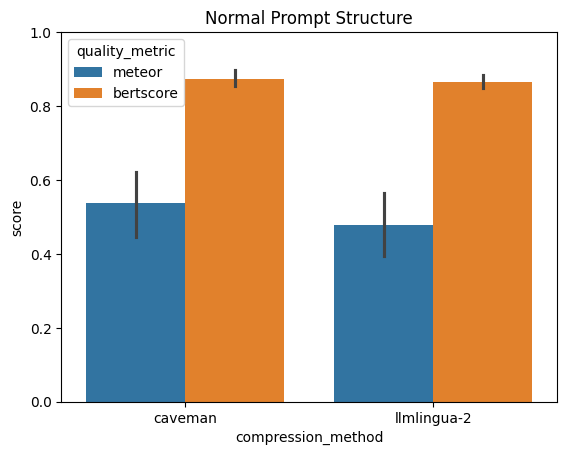

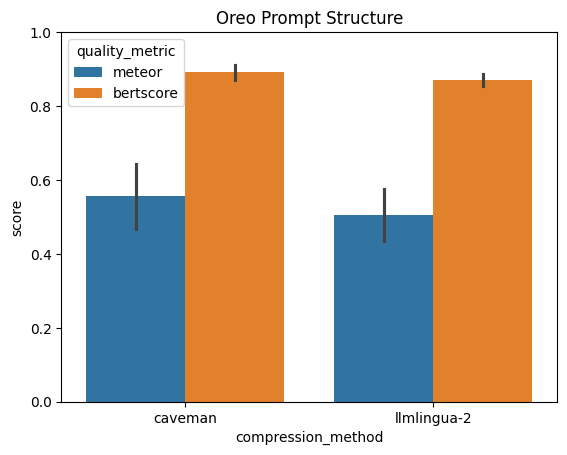

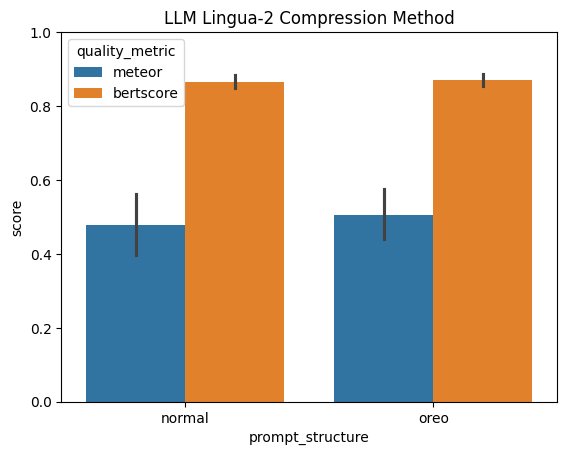

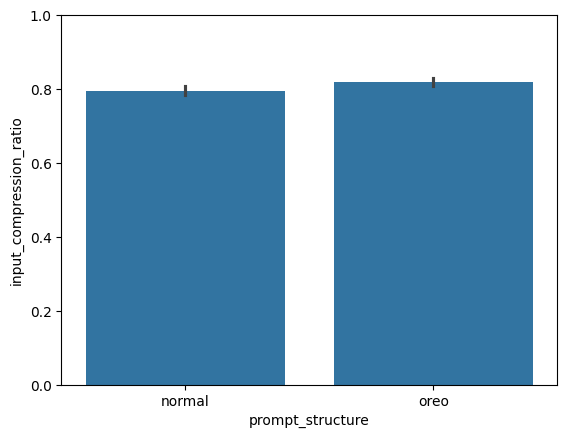

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df[df['prompt_structure'] == 'normal'], x='compression_method', y='score', hue='quality_metric').set_title('Normal Prompt Structure')
plt.ylim(0,1)
plt.show()

sns.barplot(data=df[df['prompt_structure'] == 'oreo'], x='compression_method', y='score', hue='quality_metric').set_title('Oreo Prompt Structure')
plt.ylim(0,1)
plt.show()

sns.barplot(data=df[df['compression_method'] == 'llmlingua-2'], x='prompt_structure', y='score', hue='quality_metric').set_title('LLM Lingua-2 Compression Method')
plt.ylim(0,1)
plt.show()

sns.barplot(data=df, x='prompt_structure', y='input_compression_ratio')
plt.ylim(0,1)
plt.show()

In [103]:
df.groupby(['prompt_structure', 'compression_method'])['input_compression_ratio'].agg(['mean', 'std'])#.unstack().plot.bar()

mean       std
prompt_structure compression_method                    
normal           caveman             0.813511  0.044950
                 llmlingua-2         0.777374  0.022178
oreo             caveman             0.834560  0.046154
                 llmlingua-2         0.802426  0.021155

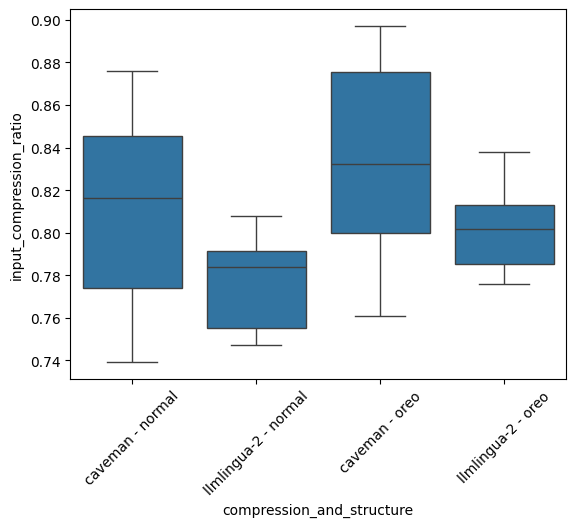

In [104]:
df['compression_and_structure'] = df['compression_method'] + ' - ' + df['prompt_structure']

sns.boxplot(data=df, x='compression_and_structure', y='input_compression_ratio')
plt.xticks(rotation=45)
plt.show()

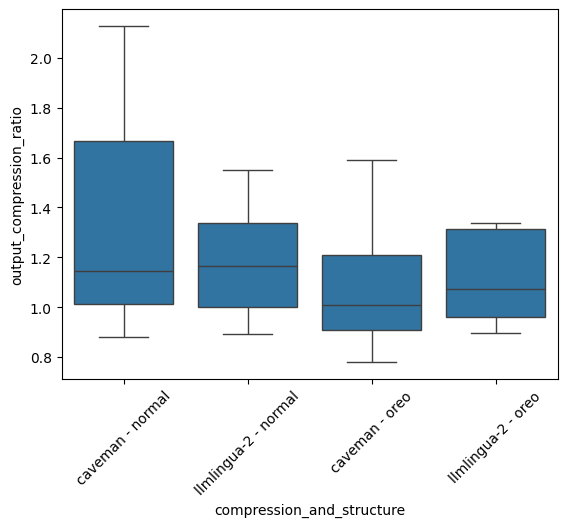

In [105]:
sns.boxplot(data=df, x='compression_and_structure', y='output_compression_ratio')
plt.xticks(rotation=45)
plt.show()

In [86]:
# pip install tiktoken
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4")  # GPT-4 family tokenizer
text = "Firstly, a token is a meaningful part of a word"
ids = enc.encode(text)

# Show each token as text (approximate “pieces”)
pieces = [enc.decode([i]) for i in ids]
print(pieces)
print("Token count:", len(ids))

['First', 'ly', ',', ' a', ' token', ' is', ' a', ' meaningful', ' part', ' of', ' a', ' word']
Token count: 12


In [108]:
compression_results = []

for prompt in prompts:

    full_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
    #prompt ID:
    prompt_id = ' '.join(full_prompt.split(' ')[:5])
    # Control Results
    control_response = send_prompt(client, full_prompt)

    for compression in [1, 0.8, 0.6, 0.4, 0.2]:

        #Oreo LLMLingua-2
        oreo_llmlingua_compressed_content = LLMlingua_compress(prompt["content"], rate=compression)
        llmlingua_compressed_prompt = prompt["system_instructions"] + "\n" + oreo_llmlingua_compressed_content + "\n" + prompt["query"]
        oreo_llmlingua_response = send_prompt(client, llmlingua_compressed_prompt)
        llmlingua_oreo_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                                test_prompt=llmlingua_compressed_prompt, test_response=oreo_llmlingua_response,
                                                method='llmlingua-2', prompt_structure='oreo', prompt_id=prompt_id, compression=compression)
        compression_results.extend(llmlingua_oreo_metrics)

In [109]:
df_compression = pd.DataFrame(compression_results)
df_compression

,prompt_id,compression_method,prompt_structure,contol_n_input_tokens,test_n_input_tokens,input_compression_ratio,control_n_output_tokens,test_n_output_tokens,output_compression_ratio,quality_metric,score,compression
0,You are a helpful assistant.,llmlingua-2,oreo,281,287,1.021352,86,87,1.011628,meteor,0.475261,1.0
1,You are a helpful assistant.,llmlingua-2,oreo,281,287,1.021352,86,87,1.011628,bertscore,0.895477,1.0
2,You are a helpful assistant.,llmlingua-2,oreo,281,218,0.775801,86,70,0.813953,meteor,0.268306,0.8
3,You are a helpful assistant.,llmlingua-2,oreo,281,218,0.775801,86,70,0.813953,bertscore,0.828781,0.8
4,You are a helpful assistant.,llmlingua-2,oreo,281,159,0.565836,86,92,1.069767,meteor,0.435924,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...
95,You are a software documentation,llmlingua-2,oreo,417,241,0.577938,62,78,1.258065,bertscore,0.871648,0.6
96,You are a software documentation,llmlingua-2,oreo,417,166,0.398082,62,63,1.016129,meteor,0.572220,0.4
97,You are a software documentation,llmlingua-2,oreo,417,166,0.398082,62,63,1.016129,bertscore,0.896816,0.4
98,You are a software documentation,llmlingua-2,oreo,417,85,0.203837,62,88,1.419355,meteor,0.411789,0.2


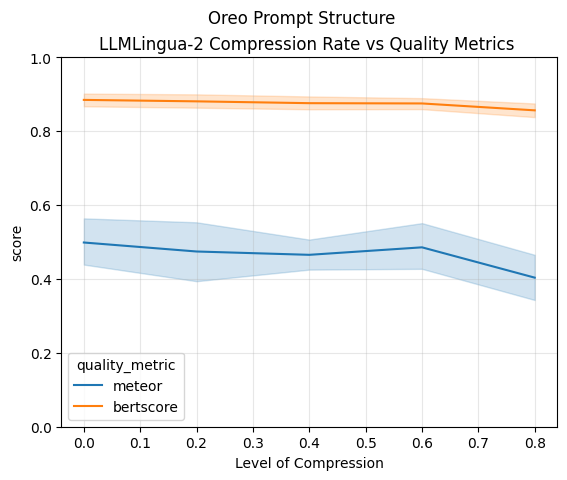

In [116]:
df_compression['Level of Compression'] = 1 - df_compression['compression']
sns.lineplot(data=df_compression, x='Level of Compression', y='score', hue='quality_metric')
plt.ylim(0,1)
plt.grid(True, alpha=0.3)  # Add this line
plt.title('LLMLingua-2 Compression Rate vs Quality Metrics ')
plt.suptitle('Oreo Prompt Structure')
plt.show()